<a href="https://colab.research.google.com/github/LucasDiiorio/econ5200-lab04-outlier-pipeline/blob/main/lab_ch04_diagnostic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4: Production Outlier Pipeline — Diagnostic Lab

**ECON 5200: Causal Machine Learning & Applied Analytics**

This lab uses a **diagnosis-first** format. You will:
1. Find and fix 3 bugs in a broken outlier detection pipeline
2. Read and run a finished `OutlierDetector` class, saved as a `.py` module
3. Compare three outlier detection methods on California Housing and write a method selection memo

**Time estimate:** about 60 minutes (Part 0: 15 min, Part 1: 30 min, Part 2: 15 min; Part 3 is take-home)

**Prerequisites:** Chapter 4 reading, including [5200-DEPTH] sections on robust statistics and breakdown points

**AI in the manual parts:** you may ask Colab to *explain* an error or a line of code (click **Explain error**, or select a line and ask Gemini to explain it). Do not ask it to write or fix code, and turn off AI code completion while you work on those parts. AI-assisted coding is allowed only where this lab says so.

## Setup

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.ensemble import IsolationForest

df = fetch_california_housing(as_frame=True).frame

print(f"{df.shape[0]:,} rows, {df.shape[1]} columns")
df.head()

20,640 rows, 9 columns


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


<!-- 5200-onramp -->
## Part 0: Build It First (GUIDED — 15 min)

Part 2 gives you `outlier_detector.py`, a module built around an
`OutlierDetector` **class**. To read it you need three tools this part covers:
dictionaries, the scikit-learn **estimator** pattern, and `class` — what
`__init__` and `self` actually do.

### Step 0a: dictionaries, and the estimator pattern

A **dictionary** is a lookup table. A list answers "what is in position 2?";
a dictionary answers "what is the value for `k`?" In this course dictionaries
mostly hold settings and results.

An **estimator** is how every model in this course works, in three steps:

1. **Build** it with settings: `model = IsolationForest(contamination=0.05)`
2. **Fit** it to data: `model.fit(X)`. The model now *remembers* what it learned.
3. **Ask** it: `model.predict(X)`

`np.mean(x)` is a function: you hand it data, it answers, it forgets. An
estimator is an object that keeps what it learned. Values it learned end in
an underscore, like `model.n_features_in_`.

In [19]:
# GUIDED — run as-is
# Step 0a: dictionaries, and the estimator pattern

settings = {"method": "tukey", "k": 1.5, "contamination": 0.05}
print(settings["method"], settings["k"])
for name, value in settings.items():
    print(" ", name, value)

X = df[["MedInc", "HouseAge", "AveRooms"]]

model = IsolationForest(contamination=0.05, random_state=42)   # 1. build
model.fit(X)                                                    # 2. fit
flags = model.predict(X)                                        # 3. ask: -1 = outlier

n_flagged = (flags == -1).sum()
print(f"\nIsolation Forest flagged {n_flagged:,} of {len(flags):,} rows "
      f"({n_flagged / len(flags):.1%})")
# n_features_in_ ends in _ because the model learned it from the data
print(f"The fitted model remembers it saw {model.n_features_in_} features")

tukey 1.5
  method tukey
  k 1.5
  contamination 0.05

Isolation Forest flagged 1,032 of 20,640 rows (5.0%)
The fitted model remembers it saw 3 features


### Step 0b: writing your own class

A **class** is a blueprint for an object that holds settings and learned
values. Three words cover it:

| Word | What it is |
|---|---|
| `__init__` | runs when you write `TukeyDetector(...)`; stores the settings |
| `self` | the object itself; how a method reaches what `__init__` stored |
| attribute | a value stored on the object, such as `self.k` |

scikit-learn's convention, which Part 2 follows: settings have plain names
(`self.k`), values learned from data end in an underscore (`self.lower_`), and
`.fit()` returns `self`, so `.fit(x).detect(x)` works in one line. Inside the
class, use `self.k`, never a literal `1.5`, or the setting does nothing.

One more piece: `raise` stops the program with an error message, and
`try` / `except` catches that error so the notebook keeps going. The last lines
of the cell show `detect()` refusing to run before `fit()`.

In [20]:
# GUIDED — run as-is
# Step 0b: writing your own class

class TukeyDetector:
    """Flag values outside the Tukey fences. A small version of Part 2's class."""

    def __init__(self, k=1.5):
        self.k = k            # a setting
        self.lower_ = None    # learned by fit()
        self.upper_ = None

    def fit(self, series):
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        self.lower_ = q1 - self.k * iqr
        self.upper_ = q3 + self.k * iqr
        return self

    def detect(self, series):
        if self.lower_ is None:
            raise RuntimeError("call .fit() before .detect()")
        return (series < self.lower_) | (series > self.upper_)


prices = df["MedHouseVal"]
print(f"prices run from {prices.min():.2f} to {prices.max():.2f}\n")

for k in [1.5, 3.0]:
    det = TukeyDetector(k=k).fit(prices)
    n_flagged = det.detect(prices).sum()
    print(f"k={k}  fences [{det.lower_:.3f}, {det.upper_:.3f}]  flagged {n_flagged:,}")

# detect() before fit() raises the error written above
try:
    TukeyDetector().detect(prices)
except RuntimeError as e:
    print(f"\nTukeyDetector().detect(...) -> RuntimeError: {e}")

prices run from 0.15 to 5.00

k=1.5  fences [-0.981, 4.824]  flagged 1,071
k=3.0  fences [-3.158, 7.001]  flagged 0

TukeyDetector().detect(...) -> RuntimeError: call .fit() before .detect()


### Now diagnose

You have now used somebody else's estimator and written your own. Part 2's
`OutlierDetector` has the same shape with three changes: it offers three
methods instead of one, it merges `fit` and `detect` into one `fit_detect()`,
and it checks its settings when you build it. It also labels its arguments
with type hints: `data: pd.Series` means "this should be a pandas Series".
Python does not enforce the label; it is there for the reader.

Notice what the `k=3.0` run just told you, because Part 1 turns on it: prices
stop at 5.00, but the upper fence sits at 7.00, so it flagged nothing at all.
A detector that returns zero is not evidence of clean data. It is a result that
needs explaining, and "the fence is beyond the largest value in the data" is
usually the explanation.

---

## Part 1: Find and Fix the Bugs (DIAGNOSTIC — 30 min)

You’ve been given an outlier detection pipeline that has **3 bugs**. Each bug represents a common mistake that even experienced data scientists make. Your job: find each bug, explain why it’s wrong, and fix it.

The pipeline implements three methods:
- **Modified Z-score** (robust, using median and MAD)
- **Tukey Fences** (IQR-based, the box plot rule)
- **Isolation Forest** (tree-based anomaly detection)

**Hint:** The bugs are related to:
- Robustness (which center/spread measure is used)
- A classic off-by-memory constant
- A hyperparameter set to an absurd value

In [21]:
# BROKEN CODE — find and fix the 3 bugs

def modified_zscore_broken(series, threshold=3.5):
    """Modified Z-score: a robust score built from the median and the MAD."""
    center = series.mean()
    spread = series.std()
    z_scores = (series - center) / spread
    return np.abs(z_scores) > threshold


def tukey_fence_broken(series, k=1.0):
    """Tukey fences: flag values below Q1 - k*IQR or above Q3 + k*IQR."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)


def isolation_forest_broken(df_numeric, contamination=0.5, random_state=42):
    """Isolation Forest: flag the rows that take the fewest splits to isolate."""
    iso = IsolationForest(contamination=contamination, random_state=random_state)
    preds = iso.fit_predict(df_numeric)
    return pd.Series(preds == -1, index=df_numeric.index)

In [22]:
# RUN THE BROKEN PIPELINE — look at what it reports

test_col = df["MedInc"]                  # median income, right-skewed
numeric_cols = df.columns               # all nine columns are numbers

print(f"MedInc: mean={test_col.mean():.2f}, median={test_col.median():.2f}, "
      f"std={test_col.std():.2f}")
print(f"MedInc skewness: {test_col.skew():.2f}")
print()

# Each result is True/False per row. .sum() counts the Trues;
# .mean() is the share that is True.
z_outliers   = modified_zscore_broken(test_col)
t_outliers   = tukey_fence_broken(test_col)
iso_outliers = isolation_forest_broken(df[numeric_cols])

print(f"Modified Z-score outliers: {z_outliers.sum()} ({z_outliers.mean():.1%})")
print(f"Tukey Fence outliers:      {t_outliers.sum()} ({t_outliers.mean():.1%})")
print(f"Isolation Forest outliers: {iso_outliers.sum()} ({iso_outliers.mean():.1%})")

MedInc: mean=3.87, median=3.53, std=1.90
MedInc skewness: 1.65

Modified Z-score outliers: 215 (1.0%)
Tukey Fence outliers:      1252 (6.1%)
Isolation Forest outliers: 10320 (50.0%)


### Diagnose Each Bug

For each bug, explain:
1. **What’s wrong** (1 sentence)
2. **Why it matters** (what does the error do to the output?)
3. **The fix** (show corrected code)

---

**Bug 1** — Modified Z Score with Mean:

*What’s wrong:
The construction of the modified Z-score should use the median and MAD. The code chunk utilizes the mean and the standard deviation*

*Why it matters: If the goal is to account for outliers in the dataset, then using the mean and the standard deviation does not achieve this goal as they are sensitive to outliers. Outliers are masked by inflating the standard deviation causing the calculated z-scores to be lower*

*Your fix:* (in the cell below)

---

**Bug 2** — Incorrect Tukey Fence:

*The current Tukey fence sets the k= 1.0 and not the standard k = 1.5.  *

*Data sets that are roughly normal distribution should have k=1.5. By making the k=1.0 some of the observations that are not outliers*

*Your fix:* (in the cell below)

---

**Bug 3** - Incorrect Contamination Value   :

*The contamination is set to .5 instead of .05*

*The contamination value set to .5 means that half of the rows are outliers *

*Your fix:* (in the cell below)

In [23]:
# YOUR FIXES
# These start as copies of the broken code, so the checks below
# fail until you fix them. Edit each function until it does what its
# docstring says.

def modified_zscore_fixed(series, threshold=3.5):
    """Modified Z-score: 0.6745 * (x - median) / MAD, flagged when |z| > threshold."""
    center = series.median()
    mad = (series - center).abs().median()
    if mad == 0:
          mad = (series - center).abs().mean()
    z_scores = 0.6745 * (series - center) / mad
    return np.abs(z_scores) > threshold


def tukey_fence_fixed(series, k=1.5):
    """Tukey fences: flag values below Q1 - k*IQR or above Q3 + k*IQR."""
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)


def isolation_forest_fixed(df_numeric, contamination=0.05, random_state=42):
    """Isolation Forest: flag the rows that take the fewest splits to isolate."""
    iso = IsolationForest(contamination=contamination, random_state=random_state)
    preds = iso.fit_predict(df_numeric)
    return pd.Series(preds == -1, index=df_numeric.index)

In [24]:
test_col = df["MedInc"]
numeric_cols = df.columns

# RUN THE FIXED PIPELINE

z_outliers_fixed   = modified_zscore_fixed(test_col)
t_outliers_fixed   = tukey_fence_fixed(test_col)
iso_outliers_fixed = isolation_forest_fixed(df[numeric_cols])

print(f"Modified Z-score outliers: {z_outliers_fixed.sum()} ({z_outliers_fixed.mean():.1%})")
print(f"Tukey Fence outliers:      {t_outliers_fixed.sum()} ({t_outliers_fixed.mean():.1%})")
print(f"Isolation Forest outliers: {iso_outliers_fixed.sum()} ({iso_outliers_fixed.mean():.1%})")

Modified Z-score outliers: 400 (1.9%)
Tukey Fence outliers:      681 (3.3%)
Isolation Forest outliers: 1032 (5.0%)


### Verification Checkpoint 1

After fixing all 3 bugs, your results on `MedInc` should approximately match:

| Method | Outliers Flagged | Percentage |
|--------|-----------------|------------|
| Modified Z-score (threshold=3.5) | ~350–450 | ~1.7–2.2% |
| Tukey Fence (k=1.5) | ~600–750 | ~3.0–3.6% |
| Isolation Forest (contamination=0.05) | ~1032 | ~5.0% |

(Measured on this data: **400**, **681** and **1032** respectively.)

Key sanity checks:
- Modified Z-score should flag the **fewest** (most conservative with threshold=3.5)
- Tukey should flag **more than Z-score** because MedInc is right-skewed
- Isolation Forest should flag **close to 5%** because contamination=0.05
- No method should flag more than ~15% of the data

If any method flags >20%, the corresponding bug is not yet fixed.

In [25]:
# VERIFICATION — run after your fixes

checks = {
    "Z-score flags 350-450 rows":     350 <= z_outliers_fixed.sum() <= 450,
    "Tukey flags 600-750 rows":       600 <= t_outliers_fixed.sum() <= 750,
    "Isolation Forest flags ~5%":     abs(iso_outliers_fixed.mean() - 0.05) < 0.02,
    "Z-score flags fewer than Tukey": z_outliers_fixed.sum() < t_outliers_fixed.sum(),
}

for name, passed in checks.items():
    if passed:
        print("  PASS ", name)
    else:
        print("  FAIL ", name)

print()
if all(checks.values()):
    print("All checks passed. Your fixes are correct.")
else:
    print("Some checks failed. Review your fixes above.")

  PASS  Z-score flags 350-450 rows
  PASS  Tukey flags 600-750 rows
  PASS  Isolation Forest flags ~5%
  PASS  Z-score flags fewer than Tukey

All checks passed. Your fixes are correct.


---

## Part 2: The `OutlierDetector` Module (EXTENSION — 15 min)

Here is the finished class. It puts your three fixed functions behind one
interface and saves them as an importable `.py` module, which is part of what
you submit. Read it against your fixed functions: find where each one lives,
where the settings are checked, and what `summary()` returns. Then run it and
the test cell below.

In [26]:
%%writefile outlier_detector.py
"""OutlierDetector: one interface to three outlier-detection methods."""

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest


class OutlierDetector:
    """Detect outliers with one of three methods.

    method         'tukey', 'zscore' or 'isolation_forest'
    k              Tukey fence multiplier            (tukey only)
    threshold      modified Z-score cutoff           (zscore only)
    contamination  share of rows to flag             (isolation_forest only)

    After fit_detect(), the results are in mask_, n_outliers_ and pct_outliers_.
    """

    VALID_METHODS = ("tukey", "zscore", "isolation_forest")

    def __init__(self, method: str = "tukey", threshold: float = 3.5,
                 k: float = 1.5, contamination: float = 0.05,
                 random_state: int = 42):
        if method not in self.VALID_METHODS:
            raise ValueError(f"method must be one of {self.VALID_METHODS}, got '{method}'")
        if threshold <= 0:
            raise ValueError(f"threshold must be positive, got {threshold}")
        if k <= 0:
            raise ValueError(f"k must be positive, got {k}")
        if not 0 < contamination < 0.5:
            raise ValueError(f"contamination must be in (0, 0.5), got {contamination}")

        self.method = method
        self.threshold = threshold
        self.k = k
        self.contamination = contamination
        self.random_state = random_state

        self.mask_ = None
        self.n_outliers_ = None
        self.pct_outliers_ = None

    def fit_detect(self, data: pd.Series | pd.DataFrame) -> pd.Series:
        """Return a boolean mask, True for outliers.

        'tukey' and 'zscore' take one column (a Series);
        'isolation_forest' takes a DataFrame of numeric columns.
        """
        if self.method != "isolation_forest" and not isinstance(data, pd.Series):
            raise TypeError(f"'{self.method}' works on one column: pass a pd.Series")

        if self.method == "zscore":
            mask = self._zscore(data)
        elif self.method == "tukey":
            mask = self._tukey(data)
        else:
            mask = self._isolation_forest(data)

        self.mask_ = mask
        # int() and float() turn numpy numbers into plain Python ones,
        # so summary() prints cleanly
        self.n_outliers_ = int(mask.sum())
        self.pct_outliers_ = float(mask.mean())
        return mask

    def summary(self) -> dict:
        """The method, how many rows it flagged, and the parameter it used."""
        if self.mask_ is None:
            raise RuntimeError("Call fit_detect() first.")

        if self.method == "zscore":
            params = {"threshold": self.threshold}
        elif self.method == "tukey":
            params = {"k": self.k}
        else:
            params = {"contamination": self.contamination}

        return {
            "method": self.method,
            "n_outliers": self.n_outliers_,
            "pct_outliers": round(self.pct_outliers_, 4),
            "params": params,
        }

    def _zscore(self, series: pd.Series) -> pd.Series:
        median = series.median()
        mad = np.median(np.abs(series - median))
        if mad == 0:    # over half the values are identical; avoid dividing by zero
            return pd.Series(False, index=series.index)
        modified_z = 0.6745 * (series - median) / mad
        return np.abs(modified_z) > self.threshold

    def _tukey(self, series: pd.Series) -> pd.Series:
        q1 = series.quantile(0.25)
        q3 = series.quantile(0.75)
        iqr = q3 - q1
        return (series < q1 - self.k * iqr) | (series > q3 + self.k * iqr)

    def _isolation_forest(self, data: pd.Series | pd.DataFrame) -> pd.Series:
        if isinstance(data, pd.Series):
            data = data.to_frame()
        iso = IsolationForest(contamination=self.contamination,
                              random_state=self.random_state)
        preds = iso.fit_predict(data)
        return pd.Series(preds == -1, index=data.index)

Overwriting outlier_detector.py


In [27]:
# TEST — check the module works

import importlib
import outlier_detector
importlib.reload(outlier_detector)      # picks up your edits when you re-run %%writefile
from outlier_detector import OutlierDetector

print("=== Test 1: Tukey method ===")
det_tukey = OutlierDetector(method="tukey", k=1.5)
det_tukey.fit_detect(df["MedInc"])
print(det_tukey.summary())
print()

print("=== Test 2: Modified Z-score ===")
det_z = OutlierDetector(method="zscore", threshold=3.5)
det_z.fit_detect(df["MedInc"])
print(det_z.summary())
print()

print("=== Test 3: Isolation Forest ===")
det_iso = OutlierDetector(method="isolation_forest", contamination=0.05)
det_iso.fit_detect(df[numeric_cols])
print(det_iso.summary())
print()

print("=== Same rows as your Part 1 fixes? ===")
print("  Tukey:  ", (det_tukey.mask_ == t_outliers_fixed).all())
print("  Z-score:", (det_z.mask_ == z_outliers_fixed).all())
print()

print("=== Test 4: Parameter validation ===")
try:
    OutlierDetector(method="invalid")
    print("  NOT caught: method='invalid' was accepted")
except ValueError as e:
    print(f"  Caught expected error: {e}")

try:
    OutlierDetector(method="isolation_forest", contamination=0.8)
    print("  NOT caught: contamination=0.8 was accepted")
except ValueError as e:
    print(f"  Caught expected error: {e}")

=== Test 1: Tukey method ===
{'method': 'tukey', 'n_outliers': 681, 'pct_outliers': 0.033, 'params': {'k': 1.5}}

=== Test 2: Modified Z-score ===
{'method': 'zscore', 'n_outliers': 400, 'pct_outliers': 0.0194, 'params': {'threshold': 3.5}}

=== Test 3: Isolation Forest ===
{'method': 'isolation_forest', 'n_outliers': 1032, 'pct_outliers': 0.05, 'params': {'contamination': 0.05}}

=== Same rows as your Part 1 fixes? ===
  Tukey:   True
  Z-score: True

=== Test 4: Parameter validation ===
  Caught expected error: method must be one of ('tukey', 'zscore', 'isolation_forest'), got 'invalid'
  Caught expected error: contamination must be in (0, 0.5), got 0.8


### Verification Checkpoint 2

Your module tests should confirm:
- All three methods run without error on California Housing data
- `summary()` returns a dict with keys `method`, `n_outliers`, `pct_outliers`, `params`
- Invalid method name raises `ValueError`
- `contamination=0.8` raises `ValueError` (must be < 0.5)
- Tukey and Z-score results match your fixed functions from Part 1

---

## Part 3: Method Comparison — Venn Diagram (CHALLENGE — take-home)

All three methods claim to detect outliers, but they flag **different observations**. The two cells below run all three on California Housing and draw the overlap as a Venn diagram. Your work is what follows them: two interpretation questions and a 200-word memo recommending which method to use.

In [28]:
# GIVEN — install the Venn diagram package
!pip install matplotlib-venn -q

In [29]:
# GUIDED — run as-is: run all three methods and compare

mask_zscore = OutlierDetector(method="zscore", threshold=3.5).fit_detect(df["MedInc"])
mask_tukey  = OutlierDetector(method="tukey", k=1.5).fit_detect(df["MedInc"])
mask_iso    = OutlierDetector(method="isolation_forest",
                              contamination=0.05).fit_detect(df[numeric_cols])

# row labels each method flagged, as sets, so & gives the overlap
set_z = set(df.index[mask_zscore])
set_t = set(df.index[mask_tukey])
set_i = set(df.index[mask_iso])

all_three = set_z & set_t & set_i
z_and_t = set_z & set_t
z_and_i = set_z & set_i
t_and_i = set_t & set_i

print(f"Z-score flags:   {len(set_z)}")
print(f"Tukey flags:     {len(set_t)}")
print(f"IsoForest flags: {len(set_i)}")
print()
print(f"Flagged by all 3:           {len(all_three)}")
print(f"Flagged by Z-score & Tukey: {len(z_and_t)}")
print(f"Flagged by Z-score & IF:    {len(z_and_i)}")
print(f"Flagged by Tukey & IF:      {len(t_and_i)}")

Z-score flags:   400
Tukey flags:     681
IsoForest flags: 1032

Flagged by all 3:           322
Flagged by Z-score & Tukey: 400
Flagged by Z-score & IF:    322
Flagged by Tukey & IF:      377


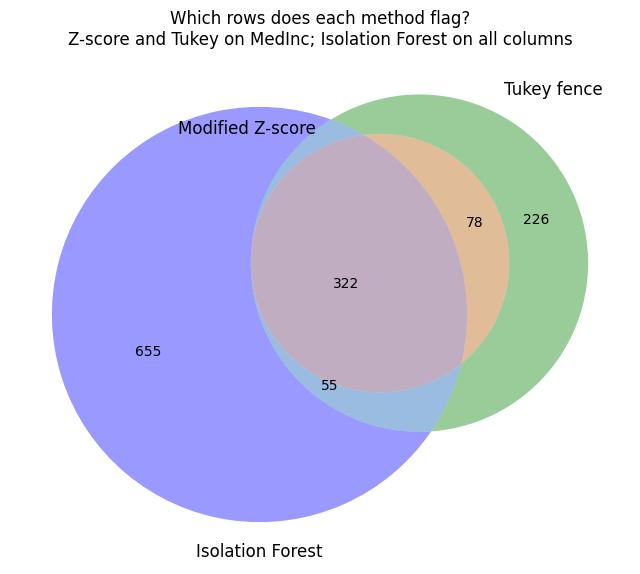

Total unique observations flagged: 1336
Flagged by >= 2 methods: 455 (34.1%)
Flagged by all 3: 322


In [30]:
# GUIDED — run as-is: draw the Venn diagram
from matplotlib_venn import venn3

fig, ax = plt.subplots(figsize=(8, 8))
venn3([set_z, set_t, set_i],
      set_labels=("Modified Z-score", "Tukey fence", "Isolation Forest"), ax=ax)
ax.set_title("Which rows does each method flag?\n"
             "Z-score and Tukey on MedInc; Isolation Forest on all columns")
plt.show()

any_flagged = set_z | set_t | set_i
at_least_two = z_and_t | z_and_i | t_and_i

print(f"Total unique observations flagged: {len(any_flagged)}")
print(f"Flagged by >= 2 methods: {len(at_least_two)} "
      f"({len(at_least_two) / len(any_flagged):.1%})")
print(f"Flagged by all 3: {len(all_three)}")

### Interpretation: Why Do Methods Disagree?

**Q1:** The Venn diagram likely shows limited overlap between Isolation Forest and the other two methods. Why? (Hint: think about what input each method receives.)

*Modified Z-scores and the Tukey Method only look at one column of the data set and flag row values that are extreme on their own. The Isolation Forest observes all numeric coulmns*

**Q2:** Modified Z-score and Tukey are both univariate and robust, yet they flag different observations. Under what distribution shape would they agree most? Disagree most?

*Modified Z-score and Tukey would likely agree the most with a dataset that has a symetric and nearly normal distribution. They likely disagree the most with data that is highly skewed. *

### Method Selection Memo (200 words)

You are a data scientist advising a policy team that uses California Housing data to allocate affordable-housing funding. They ask: "Which outlier detection method should we use to clean this data before modeling?"

Write a 200-word memo recommending a method (or combination). Address:
1. Which method and why
2. What you would lose by choosing a different method
3. Whether "outlier" always means "should be removed"

---

*I recommend to the policy team that we employ an isolation forest as the primary method to clean the dataset. The Isolation Forest looks at of the values in all of the columns. Since our funding decisions are dependent on the relationships of  multiple variables, then the Isolation Forest would be the most effective. Tukey and Z-score look only at one column and the extreme values within those columns. Out of the two the Tukey Method is the most aggregious as it may flag high income areas disproportionately. Outliers should not be dropped without these values being observed. Given that our goal is to allocate funds for affordable housing dropping extreme outliers may drop high poverty communities  *




---
## AI-Assisted Expansion: Outlier Method Explorer

**AI policy: foundations first, expansion second.** You have fixed the pipeline, built `OutlierDetector` and compared the three methods by hand. From here on, AI may write code for you (the Co-Pilot Rule).

### Your Expansion Task
Build ONE interactive explorer, inside this notebook (ipywidgets + plotly), that lets the user:
1. Pick a California Housing column
2. Tune each method's parameter — modified Z-score `threshold`, Tukey `k`, Isolation Forest `contamination`
3. See how many observations each method flags and how many all three agree on
4. Click through the flagged rows to decide whether they are errors or real extremes

Import your `OutlierDetector`; do not rewrite it.

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [31]:
# AI EXPANSION — copy the prompt below into Claude, then paste
# its code at the bottom of this cell. Run it and check it.

# [Prep] Act as an expert Python data scientist specializing
# in robust statistics and anomaly detection.
#
# [Request] I just completed a diagnosis-first lab where I fixed
# three bugs in an outlier pipeline and built an OutlierDetector
# class with method in {'zscore', 'tukey', 'isolation_forest'},
# threshold, k, contamination, a fit_detect() method and a
# summary() method, then compared the three methods on
# California Housing. Build ONE interactive explorer in Colab:
#   1. a column dropdown over the housing DataFrame df
#   2. sliders for threshold (modified Z), k (Tukey) and
#      contamination (Isolation Forest)
#   3. counts flagged by each method and by all three
#   4. a table of the flagged rows for the selected method
#
# [Iterate] Use ipywidgets, plotly and pandas. Import
# OutlierDetector from outlier_detector and reuse df. No
# Streamlit and no new .py file.
#
# [Mechanism Check] Add inline comments explaining:
#   - why the modified Z-score uses the median and MAD with the
#     0.6745 constant
#   - why Tukey fences are asymmetric on skewed data
#   - why Isolation Forest can flag rows the univariate methods
#     never will
#
# [Evaluate] Explain whether "flagged" should ever mean
# "removed" for a policy team allocating housing funds.

# PASTE AI-GENERATED CODE BELOW:
# ── Outlier explorer: modified Z vs Tukey vs Isolation Forest on `df` ──────────
# Reuses `df` (California Housing) and the lab's OutlierDetector, whose
# fit_detect() takes a pd.Series for zscore/tukey and a DataFrame for
# isolation_forest, and returns a boolean mask (True = flagged), one per row.
import importlib
from functools import lru_cache

import ipywidgets as widgets
import numpy as np
import pandas as pd
import plotly.graph_objects as go
from IPython.display import clear_output, display

import outlier_detector
importlib.reload(outlier_detector)      # picks up edits to the .py made since the first import
from outlier_detector import OutlierDetector

# Numeric columns only; remove any score or flag columns the lab added to df.
FEATURES = df.select_dtypes("number").columns.tolist()
N = len(df)
TABLE_ROWS = 25
WHOLE = [c for c in FEATURES if (df[c] % 1 == 0).all()]   # e.g. HouseAge, Population
PARAM = {"zscore": "threshold", "tukey": "k", "isolation_forest": "contamination"}
VIEWS = {"zscore": "Modified Z", "tukey": "Tukey", "isolation_forest": "Isolation Forest",
         "all": "All three", "if_only": "IF only"}
HINT = {"zscore": "lower the threshold", "tukey": "lower k",
        "isolation_forest": "raise contamination", "all": "loosen any of the three settings",
        "if_only": "raise contamination, or raise the threshold or k so fewer rows "
                   "count as univariate outliers"}
COLORS = {"zscore": "#1f77b4", "tukey": "#ff7f0e", "isolation_forest": "#2ca02c",
          "all": "#d62728", "if_only": "#9467bd"}


@lru_cache(maxsize=128)
def detect(method, cols, value):
    """Fit one OutlierDetector on df[cols]; return (detector, boolean mask on df.index).

    This is the only function that touches the OutlierDetector API, so adapt it
    here if your signature differs. The cache makes revisiting a slider value
    instant and pins Isolation Forest's random trees for each setting. It can't
    see changes to df, so re-run the cell after editing df.
    """
    # zscore/tukey take one column as a pd.Series; isolation_forest takes the DataFrame
    X = df[list(cols)] if method == "isolation_forest" else df[cols[0]]
    det = OutlierDetector(method=method, **{PARAM[method]: value})
    flags = np.asarray(det.fit_detect(X))
    if flags.dtype != bool or flags.shape[0] != len(X):
        raise TypeError(f"fit_detect returned dtype={flags.dtype}, shape={flags.shape}; expected a "
                        f"boolean mask of {len(X)} rows. For sklearn's ±1 labels, use `== -1`.")
    if flags.ndim == 2:                   # per-column flags: flagged if any column is
        flags = flags.any(axis=1)
    return det, pd.Series(flags, index=X.index)


LABEL = {"description_width": "170px"}
SLIDER = dict(continuous_update=False, style=LABEL,     # refit on release, not on every drag step
              layout=widgets.Layout(width="560px"))

col_dd = widgets.Dropdown(options=FEATURES, description="Column", style=LABEL)

# MODIFIED Z-SCORE: M = 0.6745 · (x − median) / MAD; flag |M| > threshold.
# • Why the median and MAD rather than the mean and SD: the mean and SD are
#   computed from the very rows we are trying to catch. A few extreme values
#   inflate the SD and shrink every z-score, so outliers hide themselves
#   (masking). In raw California Housing, AveOccup has an SD of about 10 but an
#   IQR under 1, so a block averaging 10 people per household gets z ≈ 0.7 and
#   passes, while its modified Z is above 10. The median and MAD have a 50%
#   breakdown point: nearly half the rows can be corrupted before either can be
#   dragged arbitrarily far, whereas one wild value can drag the mean and SD
#   anywhere.
# • Why 0.6745: it is Φ⁻¹(0.75), the 75th percentile of N(0, 1). Half of a
#   normal sample lies within ±0.6745σ of its median, so MAD ≈ 0.6745σ.
#   Multiplying by 0.6745 is the same as dividing by MAD/0.6745 ≈ 1.4826·MAD, a
#   consistent estimate of σ, so M reads on the familiar z scale and the 3.5
#   cutoff (Iglewicz & Hoaglin) means about 3.5 robust standard deviations.
# • The bounds, median ± threshold·MAD/0.6745, are symmetric about the median.
thr_sl = widgets.FloatSlider(value=3.5, min=1.0, max=10.0, step=0.1,
                             description="Threshold (modified Z)", **SLIDER)

# TUKEY FENCES: flag x < Q1 − k·IQR or x > Q3 + k·IQR.
# • The fences hang off the quartiles, not the median. Measured from the median
#   they sit (median − Q1) + k·IQR below and (Q3 − median) + k·IQR above, and
#   those differ by (Q3 − median) − (median − Q1), the quartile skew. On
#   right-skewed data the upper fence is farther out, by the same amount for
#   every k.
# • The bigger effect is the tails themselves. A long right tail crosses
#   Q3 + k·IQR, while a short left tail may never reach Q1 − k·IQR. At k = 1.5
#   the lower fence for MedInc and Population is negative, so it can never fire
#   and every flag is a high value. Watch the "< median" and "≥ median" counts
#   as you switch columns, and compare with modified Z, whose bounds sit the
#   same distance on either side of the median.
# • k = 1.5 flags about 0.7% of normal data; nothing guarantees that rate on
#   skewed data. For fences that adapt to skew deliberately, log-transform first
#   or use the medcouple-adjusted boxplot (Hubert & Vandervieren, 2008).
k_sl = widgets.FloatSlider(value=1.5, min=0.5, max=5.0, step=0.1,
                           description="k (Tukey)", **SLIDER)

# ISOLATION FOREST: random trees split a random feature at a random threshold;
# rows that are isolated after few splits (short average path) are anomalous.
# It can flag rows that modified Z and Tukey never will, for three reasons.
# • It sees the joint distribution. A row can sit inside every column's bounds
#   and still be alone in feature space: moderately many rooms with moderately
#   low income, or an ordinary profile at a sparsely populated lat/long. A
#   univariate rule tests one column at a time and cannot see combinations.
# • It scores isolation, not distance from the center, so a point in a sparse
#   gap can be flagged even when it is near the median.
# • contamination is a quota, not a cutoff. sklearn places the threshold at the
#   contamination quantile of the training scores, so about contamination × n
#   rows are flagged whether or not that many real anomalies exist, and the
#   rows filling the quota near the boundary can be quite ordinary. The
#   univariate rules, by contrast, flag nothing on a tame column like HouseAge
#   at the default settings.
# The "IF only" view lists rows that IF flags while they sit inside the
# modified-Z and Tukey bounds on every column, i.e. rows that no univariate rule
# in this explorer would flag.
con_sl = widgets.FloatSlider(value=0.05, min=0.005, max=0.25, step=0.005,
                             readout_format=".3f", description="Contamination (IF)", **SLIDER)

view_tb = widgets.ToggleButtons(options=[(label, key) for key, label in VIEWS.items()],
                                description="Show rows for",
                                style={**LABEL, "button_width": "auto"})
out = widgets.Output()


def compute(col, thr, k, con):
    """Boolean masks for the three methods plus the two derived views."""
    dets, masks = {}, {}
    for method, cols, value in [("zscore", (col,), thr), ("tukey", (col,), k),
                                ("isolation_forest", tuple(FEATURES), con)]:
        dets[method], masks[method] = detect(method, cols, value)
    univariate_any = pd.Series(False, index=df.index)    # any Z or Tukey flag on any column
    for c in FEATURES:
        univariate_any |= detect("zscore", (c,), thr)[1] | detect("tukey", (c,), k)[1]
    masks["all"] = masks["zscore"] & masks["tukey"] & masks["isolation_forest"]
    masks["if_only"] = masks["isolation_forest"] & ~univariate_any
    return dets, masks


def counts_table(masks, col, thr, k, con):
    below = df[col] < df[col].median()
    settings = {"zscore": f"|M| > {thr:g} on {col}",
                "tukey": f"k = {k:g} on {col}",
                "isolation_forest": f"contamination = {con:.3f} on all {len(FEATURES)} columns",
                "all": f"Z and Tukey on {col}, and IF",
                "if_only": "IF, inside Z and Tukey bounds on every column"}
    table = pd.DataFrame([{"rule": VIEWS[key], "setting": setting,
                           "flagged": int(masks[key].sum()), "% of rows": 100 * masks[key].mean(),
                           "< median": int((masks[key] & below).sum()),
                           "≥ median": int((masks[key] & ~below).sum())}
                          for key, setting in settings.items()]).set_index("rule")
    return (table.style.format({"% of rows": "{:.2f}%"}, thousands=",")
            .set_caption(f"Rows flagged out of {N:,}. The last two columns split each count "
                         f"at the median of {col}."))


def quantile_plot(col, mask, key):
    x = df[col].to_numpy()
    pct = df[col].rank(pct=True).to_numpy() * 100
    order = np.argsort(x)
    curve = np.r_[order[:: max(1, N // 1500)], order[-1]]   # thin the gray curve, keep the max
    m = mask.to_numpy()
    log_y = bool(x.min() > 0 and df[col].skew() > 1)         # long right tail: use a log axis
    fig = go.Figure([
        go.Scatter(x=pct[curve], y=x[curve], mode="lines", name="all rows",
                   line=dict(color="lightgray", width=3), hoverinfo="skip"),
        go.Scatter(x=pct[m], y=x[m], mode="markers", name=f"flagged: {VIEWS[key]}",
                   marker=dict(size=5, color=COLORS[key]), customdata=df.index[m],
                   hovertemplate="row %{customdata}<br>" + col +
                                 " = %{y:.3f}<br>percentile %{x:.1f}<extra></extra>"),
    ])
    fig.add_hline(y=float(np.median(x)), line_dash="dot", line_color="gray",
                  annotation_text="median")
    fig.update_layout(title=f"{VIEWS[key]}: where the flagged rows fall in {col}",
                      xaxis_title=f"Percentile rank of {col}",
                      yaxis_title=f"{col} (log scale)" if log_y else col,
                      yaxis_type="log" if log_y else "linear",
                      height=380, margin=dict(l=60, r=20, t=50, b=40), legend=dict(x=0.01, y=0.99))
    return fig


def flagged_table(masks, col, key):
    m = masks[key]
    if not m.any():
        print(f"No rows are flagged for “{VIEWS[key]}” at these settings. To see some, {HINT[key]}.")
        return
    agree = pd.DataFrame({"Z": masks["zscore"], "Tukey": masks["tukey"],
                          "IF": masks["isolation_forest"]})[m]
    distance = (df.loc[m, col] - df[col].median()).abs()
    ranked = pd.DataFrame({"n": agree.sum(axis=1), "d": distance})
    top = ranked.sort_values(["n", "d"], ascending=False).index[:TABLE_ROWS]
    shown = df.loc[top].copy()
    shown.insert(0, "flagged by",
                 agree.loc[top].apply(lambda r: " + ".join(agree.columns[r.to_numpy()]), axis=1))
    display(shown.style.format(precision=3, thousands=",").format("{:,.0f}", subset=WHOLE)
            .set_properties(subset=[col], **{"font-weight": "bold"})
            .set_caption(f"{VIEWS[key]}: top {len(shown)} of {int(m.sum()):,} flagged rows, "
                         f"sorted by how many methods agree, then by distance from the median "
                         f"of {col}. In “flagged by”, Z and Tukey refer to {col}."))


def show_summary(det):
    try:
        s = det.summary()
    except Exception as e:                    # summary() is a nice-to-have; keep the table
        print(f"summary() raised {e!r}")
        return
    if isinstance(s, str):
        print(s)
    elif s is not None:
        display(s)


def refresh(_=None):
    with out:                                 # errors show up inside the explorer, not lost
        clear_output(wait=True)
        col, key = col_dd.value, view_tb.value
        thr, k, con = round(thr_sl.value, 4), round(k_sl.value, 4), round(con_sl.value, 4)
        dets, masks = compute(col, thr, k, con)
        display(counts_table(masks, col, thr, k, con))
        quantile_plot(col, masks[key], key).show()
        if key in dets:
            print(f"{VIEWS[key]} detector summary():")
            show_summary(dets[key])
        flagged_table(masks, col, key)


for w in (col_dd, thr_sl, k_sl, con_sl, view_tb):
    w.observe(refresh, names="value")

display(widgets.VBox([
    widgets.HTML(f"Modified Z and Tukey score the selected column. Isolation Forest scores all "
                 f"{len(FEATURES)} numeric columns at once, so its count ignores the dropdown."),
    col_dd, thr_sl, k_sl, con_sl, view_tb, out,
]))
refresh()

### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1. One thing thing that AI got wrong was it used this code X = df[list(cols)]. The problem is that Claude utilized a detect() which passes a one-column Data Frame but the fit_detect wants a single pd.series
2. When running the code generated by Claude  in the Google Co-Lab an error prompted which gemini pointed out was an incorrect use of the  of the detect()
3.

---
## Digital Portfolio: your README

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.** Replace every `[YOUR VALUE]` with the number from your own output before you paste it.

In [32]:
# README prompt — documentation only, no code

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Diagnosed and fixed three bugs in an outlier-detection pipeline
# * Used an OutlierDetector class (modified Z-score, Tukey fences,
#   Isolation Forest) that checks its settings and reports a summary
# * Modified Z-score on MedInc flagged [400], Tukey on MedInc
#   [681], Isolation Forest on all 9 columns [1032];
#   all three agreed on [322]
# * Wrote a method-selection memo recommending [I recommend Isolation Forest as the primary method, with Modified Z-score on MedInc as a secondary check, since funding decisions depend on relationships across variables (income vs. location, age, room count) that Isolation Forest can catch but Tukey and Z-score — which only flag extremes in a single column — would miss entirely; between the two univariate methods, Z-score is the better secondary choice because MedInc is right-skewed, and Tukey's fixed 1.5×IQR rule over-flags the high end, putting exactly the high-income tracts we shouldn't discard by default at risk. Choosing Tukey alone would mean over-flagging legitimate high-income areas while missing multivariate anomalies entirely. Finally, "outlier" should not be read as "remove": a flag can mean data error or a real, policy-relevant extreme like a high-poverty tract, and auto-dropping flagged rows risks erasing the very communities this funding is meant to find — so flagged rows should go to review, not automatic deletion.]
# * Built an interactive outlier method explorer
#
# **Please write a README.md entry including:**
# 1. Project Title: Outlier Detection on California Housing
# 2. Objective: one sentence
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Write it plainly, in the first person. No words like 'robust',
# 'comprehensive' or 'leverage'. Use only the numbers I gave you."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ5200-lab04-outlier-pipeline`

**First time?** Read the **GitHub Setup and Repository Guide** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ5200-lab04-outlier-pipeline`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ5200-lab04-outlier-pipeline`, branch `main`,
   commit message `Lab 04 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the README prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. `outlier_detector.py` is **not** pushed by step 2 — that step sends the notebook only,
   and the file lives in Colab's temporary storage, which is wiped when the
   session ends. Download it first: in the Colab **Files** panel (folder icon,
   left), right-click `outlier_detector.py` → **Download**. Then on the repo page use
   **Add file → Upload files**, drag it in, and **Commit changes**. It is part
   of what is graded.
5. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**End of Lab 4.** You fixed three bugs in an outlier pipeline, ran the same
three methods through one class, and saw that they flag different rows. Which
rows count as outliers is a choice you make and defend, not something the data
decides for you.